# GLM-5.3-Flash on CMP 170HX (SM80) — NVFP4 incompatible, llama.cpp fallback

| Metric | Value |
|---|---|
| Decode, c=1 (UD-IQ4_XS fallback) | 17.73 tok/s |
| Best aggregate | 17.7 tok/s (flat from c=1 to c=4) |
| Prefill | untested |
| TTFT | untested |

![compatibility chart](../assets/charts/2026-08-31-glm-5.3-flash-compatibility-cmp170hx.png)

```
hf download unsloth/GLM-5.3-Flash-GGUF --revision 2975ab414d30340466d8c51533c6e91f0cca64c1 --include "UD-IQ4_XS/*" --local-dir <weights>
```

[Evidence: PixelML/GLM-5.3-Flash-CMP-170HX](https://github.com/PixelML/GLM-5.3-Flash-CMP-170HX)


# GLM-5.3-Flash on CMP 170HX — compatibility review (negative result) + llama.cpp UD-IQ4_XS fallback

Compatibility-only review of every known GLM-5.3-Flash checkpoint against a
4x NVIDIA CMP 170HX node (SM80, 64 GiB HBM2e each), measured 2026-08-30 and
written up 2026-08-31.

**This is a negative result.** The headline candidate — the NVFP4
checkpoint on a vLLM serving path — is **incompatible with SM80** and was
never executed (blocked before download). The one lane that clears both
blockers (static fit *and* a buildable SM80 runtime) is the unsloth GGUF
UD-IQ4_XS checkpoint on the sm_80 llama.cpp fork, which served and
benchmarked at **17.73 tok/s** median single-stream decode — a
compatibility fallback, not a performance result.

Evidence source: `results/2026-08-31-glm-5.3-flash-compatibility-cmp170hx/`
(receipts copied from
[PixelML/GLM-5.3-Flash-CMP-170HX](https://github.com/PixelML/GLM-5.3-Flash-CMP-170HX)).
Every claim below keeps the label its receipt carries: **measured**,
**inferred**, or **community-reported**.

In [1]:
# --- Status cell -------------------------------------------------------
# LIVE = False replays the committed receipts under results/<experiment>/.
# LIVE = True runs the same harness against a running OpenAI-compatible
# endpoint whose URL comes from an environment variable. Never hardcode an
# endpoint address in this notebook.
import os

EXPERIMENT = "2026-08-31-glm-5.3-flash-compatibility-cmp170hx"  # matches this notebook's filename, no extension
RESULTS_DIR = os.path.join("..", "results", EXPERIMENT)
LIVE = False
ENDPOINT_ENV_VAR = "GLM_BENCH_ENDPOINT_URL"  # set this env var before running with LIVE = True

print(f"experiment   : {EXPERIMENT}")
print(f"results_dir  : {RESULTS_DIR}")
print(f"LIVE         : {LIVE}")
if LIVE:
    endpoint = os.environ.get(ENDPOINT_ENV_VAR)
    if not endpoint:
        raise RuntimeError(f"LIVE=True but {ENDPOINT_ENV_VAR} is not set")
    print(f"endpoint     : from ${ENDPOINT_ENV_VAR} (not printed)")
else:
    print("endpoint     : n/a (replaying committed receipts)")


experiment   : 2026-08-31-glm-5.3-flash-compatibility-cmp170hx
results_dir  : ../results/2026-08-31-glm-5.3-flash-compatibility-cmp170hx
LIVE         : False
endpoint     : n/a (replaying committed receipts)


In [2]:
# --- Helper: receipt loader ---------------------------------------------
import json
import os


def load_receipt(name, results_dir=RESULTS_DIR):
    """Load one JSON receipt from results_dir. Raises if missing."""
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return json.load(f)


def load_text(name, results_dir=RESULTS_DIR):
    """Load one text/markdown receipt from results_dir."""
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return f.read()


def load_csv_rows(name, results_dir=RESULTS_DIR):
    """Load a telemetry CSV as a list of raw lines (sanitized values kept as strings)."""
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return f.read().splitlines()


manifest = load_receipt("run-manifest.json")
speed_c1 = load_receipt("speed-c1.json")
ladder = load_receipt("ladder.json")
soak = load_receipt("soak.json")
warmups = load_receipt("warmups.json")
results_md = load_text("RESULTS.md")
print("loaded: run-manifest.json, speed-c1.json, ladder.json, soak.json, warmups.json, RESULTS.md")
print("upstream phase:", manifest["phase"], "| date_utc:", manifest["date_utc"])


loaded: run-manifest.json, speed-c1.json, ladder.json, soak.json, warmups.json, RESULTS.md
upstream phase: C | date_utc: 2026-08-30


In [3]:
# --- Helper: table renderer ----------------------------------------------
from IPython.display import display, Markdown


def render_table(headers, rows):
    """Render a list-of-lists as a Markdown table with the given headers.
    Every header should carry its unit, e.g. 'Decode (tok/s)'."""
    lines = ["| " + " | ".join(headers) + " |",
             "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(c) for c in row) + " |")
    display(Markdown("\n".join(lines)))


## 1. TL;DR

**Verdict: FAIL for the NVFP4/vLLM lane on SM80** (pass/fail stated plainly:
the NVFP4 checkpoint cannot be served on CMP 170HX). Two independent,
individually fatal blockers, either one sufficient:

1. `glm5_next` is absent from upstream vLLM's model registry; the only known
   support PR ([vllm#53906](https://github.com/vllm-project/vllm/pull/53906))
   is open, unmerged, and SM90+ only (**measured**: registry grep + PR
   review, 2026-08-30).
2. The serving path uses sparse-MLA attention backends
   (FLASHINFER_MLA_SPARSE_SM120/SM90 class) that do not exist for SM80
   (**measured**: registry grep + PR review, 2026-08-30).

The checkpoint was never downloaded and never executed, so no runtime error
log exists for this lane — the negative result rests on the registry/PR
review, not on a failed boot. Static fit is **not** the blocker: ~48.6 GiB
per card at TP=4 fits the 64 GiB budget on paper.

**The one positive data point** is the fallback: UD-IQ4_XS GGUF on the
sm_80 llama.cpp fork — served, benchmarked, soaked, quality-checked.

In [4]:
# Values come from the receipts loaded above (speed-c1.jsonl, ladder.jsonl,
# soak.jsonl, gpu-final.csv, summary.csv, run-manifest.json); spelled out
# here so the TL;DR table renders even if later parsing changes.
key_metrics = [
    ("Overall verdict (NVFP4 / vLLM lane)", "FAIL — incompatible on SM80, never executed (compatibility-only)"),
    ("vLLM glm5_next support", "absent from upstream registry; PR #53906 open, SM90+ only (measured 2026-08-30)"),
    ("NVFP4 static fit @ TP=4 (per card, weights only)", "~48.6 GiB of 64 GiB — fits on paper (community-reported size)"),
    ("Fallback verdict (GGUF UD-IQ4_XS, llama.cpp sm_80)", "PASS — served and benchmarked (measured)"),
    ("Fallback decode, c=1 median of 5 reps (tok/s)", 17.73),
    ("Fallback aggregate, c=2 / c=4 (tok/s)", "17.50-17.73 (flat, compute-bound)"),
    ("Fallback soak", "41/41 reps ok, 20 min at c=2"),
    ("Fallback quality (corrected 26-task pack)", "21/26 tasks, quality index 0.783"),
    ("VRAM per card, end-of-run snapshot (MiB of 65,536)", "32,656 - 42,312"),
    ("Power per card, end-of-run snapshot (W)", "40.10 - 44.49"),
    ("Cold boot time", "not captured in receipts"),
]
render_table(["Metric", "Value"], key_metrics)

| Metric | Value |
|---|---|
| Overall verdict (NVFP4 / vLLM lane) | FAIL — incompatible on SM80, never executed (compatibility-only) |
| vLLM glm5_next support | absent from upstream registry; PR #53906 open, SM90+ only (measured 2026-08-30) |
| NVFP4 static fit @ TP=4 (per card, weights only) | ~48.6 GiB of 64 GiB — fits on paper (community-reported size) |
| Fallback verdict (GGUF UD-IQ4_XS, llama.cpp sm_80) | PASS — served and benchmarked (measured) |
| Fallback decode, c=1 median of 5 reps (tok/s) | 17.73 |
| Fallback aggregate, c=2 / c=4 (tok/s) | 17.50-17.73 (flat, compute-bound) |
| Fallback soak | 41/41 reps ok, 20 min at c=2 |
| Fallback quality (corrected 26-task pack) | 21/26 tasks, quality index 0.783 |
| VRAM per card, end-of-run snapshot (MiB of 65,536) | 32,656 - 42,312 |
| Power per card, end-of-run snapshot (W) | 40.10 - 44.49 |
| Cold boot time | not captured in receipts |

### Pins

The compatibility finding spans six checkpoints; the pins below cover the
NVFP4 candidate (the negative headline) and the one lane that actually ran.
All values come from `run-manifest.json` and the attempt records in the
evidence bundle.

In [5]:
pins = [
    ("NVFP4 candidate (never downloaded)", "LibertAIDAI/GLM-5.3-Flash-NVFP4 @ 11d73216cd636238e82e1d77fe1042ffab36e7fa"),
    ("NVFP4 size (~194.4 GiB)", "community-reported (DGX recipe docs); not re-measured"),
    ("Fallback checkpoint", manifest["model"]["repo"] + " (" + manifest["model"]["quant"] + ")"),
    ("Fallback revision", manifest["model"]["revision"]),
    ("Fallback shards", str(manifest["model"]["shards"]) + " (sha256-verified vs pinned manifest)"),
    ("Fallback total bytes (measured, HF blob sum)", f"{manifest['model']['total_bytes']:,} B = {manifest['model']['total_bytes'] / 2**30:.2f} GiB"),
    ("Runtime source commit", manifest["runtime"]["repo"] + " @ " + manifest["runtime"]["commit"]),
    ("Runtime build flags", manifest["runtime"]["build_flags"]),
    ("Serve config", f"ctx={manifest['serve_config']['ctx']}, split_mode={manifest['serve_config']['split_mode']}, "
     f"tensor_split={manifest['serve_config']['tensor_split']}, parallel={manifest['serve_config']['parallel']}, "
     f"threads={manifest['serve_config']['threads']}, flash_attn={manifest['serve_config']['flash_attn']}"),
    ("Topology", manifest["host"]["gpus"] + ", layer split across 4 cards"),
    ("Driver / kernel / OS", manifest["host"]["driver"] + " / " + manifest["host"]["kernel"] + " / " + manifest["host"]["os"]),
    ("Power limit", manifest["host"]["power_limit"]),
    ("Harness git sha", manifest["harness_git_sha"]),
]
render_table(["Pin", "Value"], pins)

| Pin | Value |
|---|---|
| NVFP4 candidate (never downloaded) | LibertAIDAI/GLM-5.3-Flash-NVFP4 @ 11d73216cd636238e82e1d77fe1042ffab36e7fa |
| NVFP4 size (~194.4 GiB) | community-reported (DGX recipe docs); not re-measured |
| Fallback checkpoint | unsloth/GLM-5.3-Flash-GGUF (UD-IQ4_XS) |
| Fallback revision | 2975ab414d30340466d8c51533c6e91f0cca64c1 |
| Fallback shards | 5 (sha256-verified vs pinned manifest) |
| Fallback total bytes (measured, HF blob sum) | 156,822,111,075 B = 146.05 GiB |
| Runtime source commit | unslothai/llama.cpp @ 00699716c275498ff84d71e329178fe21cba56a6 |
| Runtime build flags | -DGGML_CUDA=ON -DCMAKE_CUDA_ARCHITECTURES=80 |
| Serve config | ctx=16384, split_mode=layer, tensor_split=1,1,1,1, parallel=1, threads=8, flash_attn=auto (fork default) |
| Topology | 4x CMP 170HX 64 GiB, layer split across 4 cards |
| Driver / kernel / OS | 610.43.03 / 6.8 / Ubuntu 22.04 |
| Power limit | not-queried (per-card configured limit not captured this phase; consistency with gpu.power_limit_w restored) |
| Harness git sha | 0a50f0f38c069559516bf66343e1083ec3ef6145 |

## 2. Visible results

The static-fit arithmetic that decides each lane, the NVFP4 blocker in
detail, and every measurement from the one lane that ran. Numbers come from
the receipts in `results/2026-08-31-glm-5.3-flash-compatibility-cmp170hx/`.

### 2.1 Static-fit table — weights-only per card

Budget: 64 GiB = 68,719,476,736 bytes per card; weights-only, before CUDA
context (~0.5-1 GiB), activations, and KV cache. Measured byte totals are
computed in code from the receipts; community-reported sizes stay literals
with their label. Three-card-era (TP=3) values are history kept per the
evidence rules.

In [6]:
BUDGET_GIB = 64.0

def gib_per_card(total_bytes, cards):
    return total_bytes / cards / 2**30

# Measured byte totals (HF API blob sums, pinned revisions, from the attempt receipts).
gguf_bytes = manifest["model"]["total_bytes"]          # measured
exl3_bytes = 175_642_157_752                            # measured (HF blob sum @ pinned rev)
awq_bytes = 212_721_952_636                             # measured (HF blob sum)
# Community-reported sizes (kept as literals, labeled).
nvfp4_gib_total = 194.4      # community-reported, "~194.4 GiB download"
fp8_card_gib = 328e9 / 4 / 2**30   # community-reported ">= ~328 GB" FP8, arithmetic exact

static_fit = [
    ("unsloth GGUF UD-IQ4_XS @ 2975ab41", f"{gguf_bytes:,} B = {gguf_bytes/2**30:.2f} GiB", "measured",
     f"{gib_per_card(gguf_bytes, 4):.2f} GiB", "48.68 GiB (+15.3 GiB)",
     "yes — llama.cpp fork 00699716, sm_80 build (measured)",
     "served + benchmarked"),
    ("Mia-AiLab EXL3/TR3 4bpw @ 25a44fdb", f"{exl3_bytes:,} B = {exl3_bytes/2**30:.2f} GiB", "measured",
     f"{gib_per_card(exl3_bytes, 4):.2f} GiB", "~54.5 GiB",
     "untested — sm_121a cubins only, no SM80 build", "blocked (compatibility-only)"),
    ("LibertAIDAI NVFP4 @ 11d73216", "~194.4 GiB", "community-reported",
     f"~{nvfp4_gib_total/4:.1f} GiB", "~64.8 GiB (over budget)",
     "no — glm5_next absent; PR #53906 SM90+; sparse-MLA SM12x backends",
     "failed (compatibility-only)"),
    ("cyankiwi AWQ-INT4 @ 3999f9bf", f"{awq_bytes:,} B = {awq_bytes/2**30:.2f} GiB", "measured",
     f"{gib_per_card(awq_bytes, 4):.2f} GiB", "66.04 GiB (over by 2.04 GiB)",
     "no — same glm5_next blocker",
     "failed static fit (3-card era); runtime-blocked on 4 cards"),
    ("zai-org official FP8 (BF16 larger)", ">= ~328 GB", "community-reported",
     f">= {fp8_card_gib:.1f} GiB (no fit)", "no fit",
     "n/a — memory", "failed (static fit)"),
    ("0xSero EXL3 3.0bpw @ 8b099bf2", "not established", "community-reported",
     "not established", "not established",
     "none — requires_custom_loader, pending_full_server",
     "not attempted; repo-reported quality gate FAIL"),
]
render_table(["Candidate (revision)", "Total bytes", "Size status",
              "Per card @ TP=4 (weights)", "Per card @ TP=3 (history)",
              "SM80 runtime", "Outcome"], static_fit)
print("Budget per card: 64 GiB =", f"{68_719_476_736:,}", "bytes (weights-only; excludes CUDA context, activations, KV cache).")
print("Reading: on the 4-card node, size alone kills only the official FP8/BF16 lane;")
print("the binding constraint everywhere else is the SM80 runtime, not arithmetic.")

| Candidate (revision) | Total bytes | Size status | Per card @ TP=4 (weights) | Per card @ TP=3 (history) | SM80 runtime | Outcome |
|---|---|---|---|---|---|---|
| unsloth GGUF UD-IQ4_XS @ 2975ab41 | 156,822,111,075 B = 146.05 GiB | measured | 36.51 GiB | 48.68 GiB (+15.3 GiB) | yes — llama.cpp fork 00699716, sm_80 build (measured) | served + benchmarked |
| Mia-AiLab EXL3/TR3 4bpw @ 25a44fdb | 175,642,157,752 B = 163.58 GiB | measured | 40.89 GiB | ~54.5 GiB | untested — sm_121a cubins only, no SM80 build | blocked (compatibility-only) |
| LibertAIDAI NVFP4 @ 11d73216 | ~194.4 GiB | community-reported | ~48.6 GiB | ~64.8 GiB (over budget) | no — glm5_next absent; PR #53906 SM90+; sparse-MLA SM12x backends | failed (compatibility-only) |
| cyankiwi AWQ-INT4 @ 3999f9bf | 212,721,952,636 B = 198.11 GiB | measured | 49.53 GiB | 66.04 GiB (over by 2.04 GiB) | no — same glm5_next blocker | failed static fit (3-card era); runtime-blocked on 4 cards |
| zai-org official FP8 (BF16 larger) | >= ~328 GB | community-reported | >= 76.4 GiB (no fit) | no fit | n/a — memory | failed (static fit) |
| 0xSero EXL3 3.0bpw @ 8b099bf2 | not established | community-reported | not established | not established | none — requires_custom_loader, pending_full_server | not attempted; repo-reported quality gate FAIL |

Budget per card: 64 GiB = 68,719,476,736 bytes (weights-only; excludes CUDA context, activations, KV cache).
Reading: on the 4-card node, size alone kills only the official FP8/BF16 lane;
the binding constraint everywhere else is the SM80 runtime, not arithmetic.


### 2.2 The NVFP4 blocker — why the lane fails before boot

From `attempt-nvfp4-vllm-sm121.md` (copied receipt, upstream status
"compatibility-only, failed", 2026-08-30):

In [7]:
nvfp4_rows = [
    ("Model registry", "glm5_next (Glm5NextForConditionalGeneration) absent from upstream vLLM registry", "measured (registry grep, 2026-08-30)"),
    ("Support PR", "vllm#53906 — open, unmerged, SM90+ only", "measured (PR review, 2026-08-30)"),
    ("Attention backend", "serving path uses sparse-MLA backends (FLASHINFER_MLA_SPARSE_SM120/SM90 class); no SM80 equivalent", "measured (registry grep + PR review)"),
    ("Static fit @ TP=4", "~48.6 GiB/card — fits on paper", "inferred (community-reported size; arithmetic exact)"),
    ("Execution", "never executed — blocked before download by the runtime incompatibility and the preserve-gate on the test node", "measured (no bytes downloaded)"),
    ("Runtime error log", "does not exist — the lane failed review, not a boot", "stated plainly"),
]
render_table(["Aspect", "Finding", "Status"], nvfp4_rows)
print()
print("Upstream receipt: attempt-nvfp4-vllm-sm121.md | The same glm5_next blocker also kills the AWQ INT4 vLLM lane;")
print("the EXL3 lane fails independently (sm_121a-only binaries). Primary sources:")
print("  - https://github.com/vllm-project/vllm/blob/main/vllm/model_executor/models/registry.py")
print("  - https://github.com/vllm-project/vllm/pull/53906")

| Aspect | Finding | Status |
|---|---|---|
| Model registry | glm5_next (Glm5NextForConditionalGeneration) absent from upstream vLLM registry | measured (registry grep, 2026-08-30) |
| Support PR | vllm#53906 — open, unmerged, SM90+ only | measured (PR review, 2026-08-30) |
| Attention backend | serving path uses sparse-MLA backends (FLASHINFER_MLA_SPARSE_SM120/SM90 class); no SM80 equivalent | measured (registry grep + PR review) |
| Static fit @ TP=4 | ~48.6 GiB/card — fits on paper | inferred (community-reported size; arithmetic exact) |
| Execution | never executed — blocked before download by the runtime incompatibility and the preserve-gate on the test node | measured (no bytes downloaded) |
| Runtime error log | does not exist — the lane failed review, not a boot | stated plainly |


Upstream receipt: attempt-nvfp4-vllm-sm121.md | The same glm5_next blocker also kills the AWQ INT4 vLLM lane;
the EXL3 lane fails independently (sm_121a-only binaries). Primary sources:
  - https://github.com/vllm-project/vllm/blob/main/vllm/model_executor/models/registry.py
  - https://github.com/vllm-project/vllm/pull/53906


### 2.3 Fallback lane (GGUF UD-IQ4_XS, llama.cpp sm_80) — protocol

The only executed lane. Protocol from `run-manifest.json`:

In [8]:
p = manifest["protocol"]
protocol_rows = [
    ("Warmups", f"{p['warmups']} discarded reps (c=1)"),
    ("c=1 measured reps", p["c1_reps"]),
    ("Prompt / completion tokens", f"~{p['prompt_tokens_approx']} in / {p['completion_tokens']} out (from the final usage object)"),
    ("Concurrency ladder", p["ladder"]),
    ("Soak", p["soak"]),
    ("Seed / temperature", f"{p['seed']} / {p['temperature']}"),
    ("Quality pack", "26 deterministic local tasks (math, instruction-following, long-context, sandboxed code); corrected pack after two harness-defect fixes"),
]
render_table(["Protocol item", "Value"], protocol_rows)

| Protocol item | Value |
|---|---|
| Warmups | 3 discarded reps (c=1) |
| c=1 measured reps | 5 |
| Prompt / completion tokens | ~400 in / 256 out (from the final usage object) |
| Concurrency ladder | 1,2,4 x 2 reps |
| Soak | 20 min at c=2, 41 reps |
| Seed / temperature | 42 / 0.0 |
| Quality pack | 26 deterministic local tasks (math, instruction-following, long-context, sandboxed code); corrected pack after two harness-defect fixes |

#### Single-stream decode, c=1 (5 measured reps)

400-token prompt / 256-token completion; aggregate tok/s = completion
tokens / wall time from the final usage object.

In [9]:
c1 = speed_c1
c1_rows = [(r["run"], r["ok"], r["wall_s"], r["completion_tokens"], r["tok_per_s_per_req"], r["tok_per_s_aggregate"])
           for r in c1]
render_table(["Rep", "OK", "Wall time (s)", "Completion tokens (usage object)",
              "Per-request (tok/s)", "Aggregate (tok/s)"], c1_rows)
aggs = sorted(r["tok_per_s_aggregate"] for r in c1)
walls = sorted(r["wall_s"] for r in c1)
print(f"median aggregate: {aggs[len(aggs)//2]:.2f} tok/s | median wall: {walls[len(walls)//2]:.3f} s")
wu = [r["wall_s"] for r in warmups]
print(f"(3 discarded warmup reps, warmups.json: wall {wu[0]:.2f} / {wu[1]:.2f} / {wu[2]:.2f} s — first rep slower, then the steady ~14.4 s state)")

| Rep | OK | Wall time (s) | Completion tokens (usage object) | Per-request (tok/s) | Aggregate (tok/s) |
|---|---|---|---|---|---|
| 0 | True | 14.379 | 256 | 17.8 | 17.8 |
| 1 | True | 14.556 | 256 | 17.59 | 17.59 |
| 2 | True | 14.439 | 256 | 17.73 | 17.73 |
| 3 | True | 14.238 | 256 | 17.98 | 17.98 |
| 4 | True | 14.436 | 256 | 17.73 | 17.73 |

median aggregate: 17.73 tok/s | median wall: 14.436 s
(3 discarded warmup reps, warmups.json: wall 19.52 / 14.43 / 14.47 s — first rep slower, then the steady ~14.4 s state)


#### Concurrency ladder (1/2/4 x 2 reps) and soak (41 reps, c=2, 20 min)

In [10]:
lad = ladder
by_level = {}
for r in lad:
    by_level.setdefault(r["concurrency"], []).append(r)
ladder_rows = []
for c in sorted(by_level):
    reps = by_level[c]
    aggs = [r["tok_per_s_aggregate"] for r in reps]
    per = [r["tok_per_s_per_req"] for r in reps]
    ladder_rows.append((c, len(reps), min(aggs), max(aggs), f"{min(per)} - {max(per)}", "PASS"))
render_table(["Concurrency (requests)", "Reps", "Aggregate min (tok/s)",
              "Aggregate max (tok/s)", "Per-request range (tok/s)", "Status"], ladder_rows)

pass  # soak loaded in the receipt-loader cell
soak_ok = sum(1 for r in soak if r["ok"])
soak_aggs = [r["tok_per_s_aggregate"] for r in soak]
print(f"soak: {soak_ok}/{len(soak)} reps ok over 20 min | per-rep aggregate {min(soak_aggs)} - {max(soak_aggs)} tok/s "
      f"(first 3: {soak_aggs[0]}-{soak_aggs[2]}, last 3: {soak_aggs[-3]}-{soak_aggs[-1]}; upstream characterizes the band as stable 17.5 -> 17.7)")
print("c=4 aggregate equals the c=1 median within noise: the lane saturates the cards' compute, it does not scale past c=1.")

| Concurrency (requests) | Reps | Aggregate min (tok/s) | Aggregate max (tok/s) | Per-request range (tok/s) | Status |
|---|---|---|---|---|---|
| 1 | 2 | 14.99 | 17.31 | 14.99 - 17.31 | PASS |
| 2 | 2 | 17.5 | 17.53 | 13.13 - 13.14 | PASS |
| 4 | 2 | 17.69 | 17.73 | 7.38 - 7.38 | PASS |

soak: 41/41 reps ok over 20 min | per-rep aggregate 17.3 - 18.09 tok/s (first 3: 17.51-17.64, last 3: 17.66-17.74; upstream characterizes the band as stable 17.5 -> 17.7)
c=4 aggregate equals the c=1 median within noise: the lane saturates the cards' compute, it does not scale past c=1.


#### Quality (corrected 26-task pack) and end-of-run GPU snapshot

Quality comes from `summary.csv` (the corrected pack after two harness
defects were fixed mid-phase; the first pack is invalid). The snapshot is
the only telemetry this phase — see the receipt gaps in the appendix.

In [11]:
import csv, io

srow = list(csv.DictReader(io.StringIO(load_text("summary.csv"))))[0]
quality_rows = [
    ("Quality index", srow["quality_index"]),
    ("Tasks passed", f"{int(srow['n_eval_tasks']) - int(srow['n_failed_eval_tasks'])}/{srow['n_eval_tasks']}"),
    ("Bucket rates", srow["bucket_rates"]),
    ("Bucket counts", srow["bucket_counts"]),
    ("Success rate (all reps)", srow["success_rate"]),
    ("Task wall time, c=1 (s, measured e2e)", srow["t_task_s"]),
    ("Decision (upstream experiments.csv)", "baseline-below-90pct-gate — a compatibility fallback, not a performance result"),
]
render_table(["Quality metric", "Value"], quality_rows)

gpu_rows = []
for line in load_csv_rows("gpu-final.csv"):
    idx, mem, total, tcore, tmem, power = [c.strip() for c in line.split(",")]
    gpu_rows.append((f"GPU {idx}", f"{mem} / {total}", f"{tcore}", f"{tmem}", power))
render_table(["Card", "VRAM used / total (MiB)", "Core temp (C)",
              "Memory temp (C)", "Power (W, snapshot)"], gpu_rows)

| Quality metric | Value |
|---|---|
| Quality index | 0.7833 |
| Tasks passed | 16/19 |
| Bucket rates | {"math": 1.0, "instruction": 0.8, "coding": 0.3333333333333333, "longctx": 1.0} |
| Bucket counts | {"math": 8, "instruction": 5, "coding": 3, "longctx": 3} |
| Success rate (all reps) | 0.8421 |
| Task wall time, c=1 (s, measured e2e) | 14.435 |
| Decision (upstream experiments.csv) | baseline-below-90pct-gate — a compatibility fallback, not a performance result |

| Card | VRAM used / total (MiB) | Core temp (C) | Memory temp (C) | Power (W, snapshot) |
|---|---|---|---|---|
| GPU 0 | 33342 MiB / 65536 MiB | 43 | 45 | 40.10 W |
| GPU 1 | 42312 MiB / 65536 MiB | 41 | 54 | 44.49 W |
| GPU 2 | 41646 MiB / 65536 MiB | 43 | 55 | 40.64 W |
| GPU 3 | 32656 MiB / 65536 MiB | 41 | 53 | 41.82 W |

### 2.4 Chart: static fit per card vs the 64 GiB budget

The quantitative core of the finding: weights-only GiB per card at TP=4 for
each candidate, against the 64 GiB card budget. Only the official FP8 lane
fails on size; only the GGUF lane has a runtime that can use its fit.

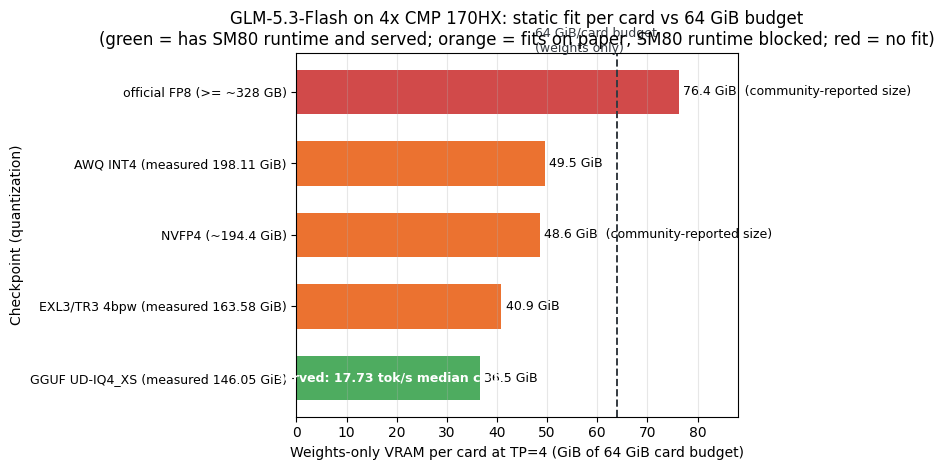

saved: assets/charts/2026-08-31-glm-5.3-flash-compatibility-cmp170hx.{png,svg}


In [12]:
import matplotlib.pyplot as plt

# (label, GiB per card @ TP=4, size provenance, outcome)
bars = [
    ("GGUF UD-IQ4_XS (measured 146.05 GiB)", gib_per_card(gguf_bytes, 4), "measured", "served"),
    ("EXL3/TR3 4bpw (measured 163.58 GiB)", gib_per_card(exl3_bytes, 4), "measured", "runtime-blocked"),
    ("NVFP4 (~194.4 GiB)", nvfp4_gib_total / 4, "community-reported", "runtime-blocked"),
    ("AWQ INT4 (measured 198.11 GiB)", gib_per_card(awq_bytes, 4), "measured", "runtime-blocked"),
    ("official FP8 (>= ~328 GB)", fp8_card_gib, "community-reported", "no fit"),
]
color = {"served": "#2f9e44", "runtime-blocked": "#e8590c", "no fit": "#c92a2a"}

fig, ax = plt.subplots(figsize=(9, 4.8))
ys = range(len(bars))
vals = [b[1] for b in bars]
ax.barh(ys, vals, color=[color[b[3]] for b in bars], alpha=0.85, height=0.62)
ax.axvline(BUDGET_GIB, color="#343a40", linestyle="--", linewidth=1.4)
ax.annotate("64 GiB/card budget\n(weights only)", xy=(BUDGET_GIB, len(bars) - 0.55),
            xytext=(BUDGET_GIB - 16.5, len(bars) - 0.45), fontsize=9, color="#343a40")

for y, (label, val, prov, outcome) in zip(ys, bars):
    prov_note = "" if prov == "measured" else "  (community-reported size)"
    ax.text(val + 0.8, y, f"{val:.1f} GiB{prov_note}", va="center", fontsize=9)
ax.text(bars[0][1] / 2, 0, "served: 17.73 tok/s median c=1", va="center", ha="center",
        fontsize=9, color="white", fontweight="bold")

ax.set_yticks(list(ys))
ax.set_yticklabels([b[0] for b in bars], fontsize=9)
ax.set_xlabel("Weights-only VRAM per card at TP=4 (GiB of 64 GiB card budget)")
ax.set_ylabel("Checkpoint (quantization)")
ax.set_title("GLM-5.3-Flash on 4x CMP 170HX: static fit per card vs 64 GiB budget\n"
             "(green = has SM80 runtime and served; orange = fits on paper, SM80 runtime blocked; red = no fit)")
ax.set_xlim(0, 88)
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()

import os
os.makedirs("../assets/charts", exist_ok=True)
fig.savefig("../assets/charts/2026-08-31-glm-5.3-flash-compatibility-cmp170hx.png", dpi=150)
fig.savefig("../assets/charts/2026-08-31-glm-5.3-flash-compatibility-cmp170hx.svg")
plt.show()
print("saved: assets/charts/2026-08-31-glm-5.3-flash-compatibility-cmp170hx.{png,svg}")

## 3. Reproduce

**Hardware.** 4x NVIDIA CMP 170HX (GA100, SM80 / compute capability 8.0,
64 GiB HBM2e each), PCIe, forced airflow. Driver 610.43.03, kernel 6.8,
Ubuntu 22.04. Per-card power limit was not queried this phase; abort at
80 C core / 85 C memory / any Xid / GPU disappearance.

**Reproducing the negative result (NVFP4 / vLLM lanes).** There is nothing
to run: the blocker is upstream software, not this node. Check
[vllm's model registry](https://github.com/vllm-project/vllm/blob/main/vllm/model_executor/models/registry.py)
for `glm5` and the state of
[vllm#53906](https://github.com/vllm-project/vllm/pull/53906) — until an
SM80-capable `glm5_next` backend lands upstream, every vLLM lane
(NVFP4, AWQ INT4) stays blocked, and EXL3 stays blocked until an ExLlamaV3
SM80 build exists. Re-run this check before assuming the conclusion still
holds.

**Reproducing the fallback (the one working lane).**

1. Checkpoint:
   [unsloth/GLM-5.3-Flash-GGUF](https://huggingface.co/unsloth/GLM-5.3-Flash-GGUF),
   revision `2975ab414d30340466d8c51533c6e91f0cca64c1`, `UD-IQ4_XS/`
   subfolder — 5 shards, **156,822,111,075 bytes = 146.05 GiB** (measured
   HF blob sum). Verify each shard against the pinned hashes in
   `results/2026-08-31-glm-5.3-flash-compatibility-cmp170hx/expected-sha256.txt`
   before serving; stage in shared model storage only, never in a repository.
2. Runtime: build the
   [unslothai/llama.cpp](https://github.com/unslothai/llama.cpp) fork at
   commit `00699716c275498ff84d71e329178fe21cba56a6` with
   `-DGGML_CUDA=ON -DCMAKE_CUDA_ARCHITECTURES=80`
   (upstream PR [ggml-org/llama.cpp#27754](https://github.com/ggml-org/llama.cpp/pull/27754)
   was still open, unmerged, at measurement time — the fork head is the
   buildable implementation).
3. Serve (paths and port masked per the publication rules; this is the
   manifest configuration):

```bash
llama-server --model <first-shard-path-of-5> --split-mode layer \
  --tensor-split 1,1,1,1 --ctx-size 16384 --parallel 1 --threads 8 \
  --port <port> --host 127.0.0.1
```

4. Bench: upstream `bench/rebench.sh` (in
   [PixelML/GLM-5.3-Flash-CMP-170HX](https://github.com/PixelML/GLM-5.3-Flash-CMP-170HX))
   wraps preflight, a continuous thermal/Xid guard, and a fresh run
   directory: 3 discarded warmups; 5 measured c=1 reps at 400 in / 256 out;
   ladder 1/2/4 x 2 reps; 20-minute c=2 soak; 26-task quality pack. Tokens
   are counted from the final usage object, never from stream events.
5. Expected: median **17.73 tok/s** aggregate at c=1 (e2e ~14.4 s per
   task), flat 17.5-17.7 tok/s aggregate at c=2/c=4, first warmup rep
   slower (~19.5 s) than the steady state. Boot/load time was not captured
   in this phase's receipts.

## 4. Appendix

<details>
<summary>Attempt history, preflight/safety, receipt gaps, and limitations (click to expand)</summary>

### 4.1 Attempt-by-attempt failure history

Every lane examined for GLM-5.3-Flash on this node, in examination order.
Failed attempts are preserved, not dropped; full records are the
`attempt-*.md` receipts in the evidence bundle.

In [13]:
history = [
    ("cyankiwi AWQ-INT4 @ 3999f9bf", "static-fit-only, failed",
     "3-card era: 66.04 GiB/card at TP=3 — 2.04 GiB over budget before any overhead; "
     "4-card fit now clears on paper (49.53 GiB/card) but glm5_next is absent from upstream vLLM"),
    ("zai-org FP8 / BF16 (official)", "static-fit-only, failed",
     ">= ~76 GiB/card at TP=4 (community-reported sizes) — no fit at either topology"),
    ("LibertAIDAI NVFP4 @ 11d73216", "compatibility-only, failed",
     "fits on paper (~48.6 GiB/card) but no SM80 runtime: glm5_next absent; PR #53906 SM90+; "
     "sparse-MLA SM12x attention backends; never downloaded"),
    ("0xSero EXL3 3.0bpw @ 8b099bf2", "not attempted",
     "no servable artifact (requires_custom_loader, pending_full_server); tokenizer files absent; "
     "repo-reported quality gate FAIL (KL 0.153 / ppl 0.093 / top-1 0.873)"),
    ("Mia-AiLab EXL3/TR3 4bpw @ 25a44fdb", "compatibility-only, failed",
     "best fit after GGUF (40.90 GiB/card) but SM121-only binaries (sm_121a cubins) and no SM80 "
     "attention backend; DGX Spark recipe exists but nothing transfers to SM80"),
    ("unsloth GGUF UD-IQ4_XS @ 2975ab41", "measured — served",
     "the only lane clearing both blockers: fits with 27.5 GiB/card margin AND a buildable sm_80 "
     "runtime; 17.73 tok/s median c=1, 21/26 quality"),
]
render_table(["Candidate", "Status", "Blocker / outcome"], history)

| Candidate | Status | Blocker / outcome |
|---|---|---|
| cyankiwi AWQ-INT4 @ 3999f9bf | static-fit-only, failed | 3-card era: 66.04 GiB/card at TP=3 — 2.04 GiB over budget before any overhead; 4-card fit now clears on paper (49.53 GiB/card) but glm5_next is absent from upstream vLLM |
| zai-org FP8 / BF16 (official) | static-fit-only, failed | >= ~76 GiB/card at TP=4 (community-reported sizes) — no fit at either topology |
| LibertAIDAI NVFP4 @ 11d73216 | compatibility-only, failed | fits on paper (~48.6 GiB/card) but no SM80 runtime: glm5_next absent; PR #53906 SM90+; sparse-MLA SM12x attention backends; never downloaded |
| 0xSero EXL3 3.0bpw @ 8b099bf2 | not attempted | no servable artifact (requires_custom_loader, pending_full_server); tokenizer files absent; repo-reported quality gate FAIL (KL 0.153 / ppl 0.093 / top-1 0.873) |
| Mia-AiLab EXL3/TR3 4bpw @ 25a44fdb | compatibility-only, failed | best fit after GGUF (40.90 GiB/card) but SM121-only binaries (sm_121a cubins) and no SM80 attention backend; DGX Spark recipe exists but nothing transfers to SM80 |
| unsloth GGUF UD-IQ4_XS @ 2975ab41 | measured — served | the only lane clearing both blockers: fits with 27.5 GiB/card margin AND a buildable sm_80 runtime; 17.73 tok/s median c=1, 21/26 quality |

### 4.2 Preflight and safety

Per `AGENTS.md`: stop at 80 C core / 85 C memory, stop on Xid / ECC / GPU
disappearance, forced airflow before load. The fallback run stayed within
limits on the telemetry that exists (end-of-run snapshot: 41-43 C core,
53-55 C memory, 40.10-44.49 W per card).

In [14]:
s = manifest["safety"]
safety_rows = [
    ("Core temp stop condition (C)", s["core_limit_c"]),
    ("Memory temp stop condition (C)", s["mem_limit_c"]),
    ("Observed core / memory temps (end-of-run snapshot)", "41-43 C / 53-55 C"),
    ("Observed power per card (end-of-run snapshot)", "40.10 - 44.49 W"),
    ("Throttle events", s["throttle_events"]),
    ("Xid events", s["xid_events"]),
    ("Thermal breaches", s["thermal_breaches"]),
    ("Per-card configured power limit", s["core_limit_c"] and manifest["host"]["power_limit"]),
]
render_table(["Check", "Value"], safety_rows)
print("Telemetry note:", s["telemetry_note"])

| Check | Value |
|---|---|
| Core temp stop condition (C) | 80 |
| Memory temp stop condition (C) | 85 |
| Observed core / memory temps (end-of-run snapshot) | 41-43 C / 53-55 C |
| Observed power per card (end-of-run snapshot) | 40.10 - 44.49 W |
| Throttle events | not-recorded (no continuous throttle telemetry this phase; final snapshot only) |
| Xid events | not-recorded (thermal-guard Xid scan ran between phases with no detected events logged; continuous kernel-log capture not committed) |
| Thermal breaches | not-recorded (no continuous thermal-breach telemetry committed; guard checks ran between phases) |
| Per-card configured power limit | not-queried (per-card configured limit not captured this phase; consistency with gpu.power_limit_w restored) |

Telemetry note: single snapshot at end of run + bounded guard calls between stages; continuous watch telemetry for the soak is a known gap in this run and is enforced in bench/rebench.sh for future runs


### 4.3 Receipt gaps (stated plainly, not invented around)

- **No NVFP4 runtime log exists.** The lane was never executed; the
  incompatibility is established by registry/PR review (measured
  2026-08-30), not by a failed boot. There is no "load attempt crashed"
  output to show.
- **NVFP4 and official FP8/BF16 sizes are community-reported**, not
  re-measured via the HF API (the measured byte totals in the static-fit
  table — GGUF, EXL3 4bpw, AWQ — are HF blob sums at pinned revisions).
- **No continuous thermal/Xid telemetry** for the fallback run: a single
  end-of-run snapshot plus bounded guard calls between phases; the
  `run-manifest.json` safety block records throttle events, continuous Xid
  capture, thermal breaches, and the per-card configured power limit as
  `not-recorded`. No fault-free-operation claim is made for the soak window.
- **Quality receipts lack finish/reasoning fields**, so the two coding
  misses and two held-out instruction misses in the 21/26 pack have no
  per-miss diagnosis; the two harness defects found mid-phase (sandbox
  wrapper dropping the candidate module; completion budgets starving
  reasoning output) were fixed and the corrected pack is the one reported.
- **EXL3 3.0bpw size/quality are community-reported** from the checkpoint
  card; not re-measured.

### 4.4 What this result does and does not show

**Shows (measured unless labeled):** the NVFP4 checkpoint is incompatible
with SM80 as of 2026-08-30 because no runtime can serve it — a
software/registry fact, checked against primary sources, not a hardware
defect of CMP 170HX. Size is not the NVFP4 blocker on the 4-card node. The
UD-IQ4_XS GGUF + sm_80 llama.cpp pairing is the one servable lane and its
throughput/quality envelope is measured (17.73 tok/s median c=1; flat
17.5-17.7 tok/s to c=4; 21/26 quality).

**Does not show:**

- That NVFP4 can never work on SM80 — only that no known runtime supported
  it on 2026-08-30. Re-check the registry and PR #53906 before reuse
  (untested beyond that date).
- Performance claims for the fallback: 17.73 tok/s is far below the club's
  90%-of-reference gate (decision `baseline-below-90pct-gate`); it is a
  compatibility datapoint.
- Anything about c>4, longer contexts, or the mmap-vs-RAM constraint
  beyond the receipts (146.05 GiB weights vs 94 GiB host RAM makes
  `--no-mmap` infeasible — inferred, static arithmetic).
- Any quality diagnosis of individual model misses (receipt fields absent).

**Links.**

- Upstream evidence repo: [PixelML/GLM-5.3-Flash-CMP-170HX](https://github.com/PixelML/GLM-5.3-Flash-CMP-170HX)
  (attempt records + phase-C receipts copied into this bundle)
- vLLM registry: [model_executor/models/registry.py](https://github.com/vllm-project/vllm/blob/main/vllm/model_executor/models/registry.py)
- vLLM support PR (open, SM90+): [vllm#53906](https://github.com/vllm-project/vllm/pull/53906)
- llama.cpp GLM-DSA PR (open): [ggml-org/llama.cpp#27754](https://github.com/ggml-org/llama.cpp/pull/27754)
- DGX reference recipe: [PixelML/GLM-5.3-Flash-NVFP4-Dual-DGX-Spark](https://github.com/PixelML/GLM-5.3-Flash-NVFP4-Dual-DGX-Spark)

</details>